In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

In [2]:
PROJECT_ROOT = Path.cwd().parent

FEATURES_PATH = (
    PROJECT_ROOT /
    "outputs" /
    "natural_sound_features.csv"
)

features_df = pd.read_csv(FEATURES_PATH)

print(features_df.shape)

features_df.head()

(520, 14)


,mean,std,min,max,skewness,kurtosis,rms,entropy,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,filename,category
0,-0.000001,0.061434,-0.480499,0.545563,0.392988,10.404342,0.061434,2.948086,0.157994,4042.281204,2643.109696,6623.483383,1-100038-A-14.wav,chirping_birds
1,-0.000003,0.010946,-0.082306,0.102997,0.157899,8.572530,0.010946,3.013087,0.027574,2075.738865,3455.603120,4559.843116,1-101296-A-19.wav,thunderstorm
2,-0.000010,0.016860,-0.164459,0.156952,-0.039740,10.883121,0.016860,2.866590,0.028877,1850.646524,3093.555844,3547.033153,1-101296-B-19.wav,thunderstorm
3,-0.000253,0.136177,-0.945587,0.999969,0.027326,2.776779,0.136177,3.313940,0.041329,2675.116865,3530.183905,6261.615656,1-103298-A-9.wav,crow
4,-0.000025,0.063967,-0.816681,0.980133,-0.052734,29.311878,0.063967,2.170481,0.010723,446.951318,1005.672928,696.156966,1-115521-A-19.wav,thunderstorm


In [3]:
features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean                520 non-null    float64
 1   std                 520 non-null    float64
 2   min                 520 non-null    float64
 3   max                 520 non-null    float64
 4   skewness            520 non-null    float64
 5   kurtosis            520 non-null    float64
 6   rms                 520 non-null    float64
 7   entropy             520 non-null    float64
 8   zcr                 520 non-null    float64
 9   spectral_centroid   520 non-null    float64
 10  spectral_bandwidth  520 non-null    float64
 11  spectral_rolloff    520 non-null    float64
 12  filename            520 non-null    str    
 13  category            520 non-null    str    
dtypes: float64(12), str(2)
memory usage: 57.0 KB


In [4]:
feature_columns = [

    "mean",
    "std",
    "min",
    "max",

    "skewness",
    "kurtosis",

    "rms",

    "entropy",

    "zcr",

    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_rolloff"
]

X = features_df[feature_columns]

print(X.shape)

(520, 12)


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(520, 12)


In [6]:
pd.DataFrame(
    X_scaled,
    columns=feature_columns
).describe().round(2)

,mean,std,min,max,skewness,kurtosis,rms,entropy,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff
count,520.00,520.00,520.00,520.00,520.00,520.00,520.00,520.00,520.00,520.00,520.00,520.00
mean,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-20.22,-0.99,-1.35,-1.82,-20.11,-0.19,-0.99,-2.75,-1.02,-1.49,-2.21,-1.60
25%,0.02,-0.74,-0.89,-0.87,-0.02,-0.19,-0.74,-0.71,-0.70,-0.76,-0.81,-0.88
50%,0.02,-0.17,-0.13,0.05,0.02,-0.17,-0.17,0.25,-0.26,-0.15,0.02,-0.11
75%,0.02,0.37,0.93,0.92,0.06,-0.14,0.36,0.79,0.35,0.54,0.82,0.71
max,9.66,6.44,1.82,1.34,7.82,17.48,6.41,1.93,6.90,5.05,2.51,2.86


In [7]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(520, 12)


In [8]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[3.66070592e-01 1.89650817e-01 1.51261729e-01 1.01472004e-01
 7.76205624e-02 5.52912131e-02 2.97345473e-02 2.08683719e-02
 3.87665351e-03 3.01317532e-03 1.08118874e-03 5.91459187e-05]


In [9]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.36607059 0.55572141 0.70698314 0.80845514 0.8860757  0.94136692
 0.97110146 0.99196984 0.99584649 0.99885967 0.99994085 1.        ]


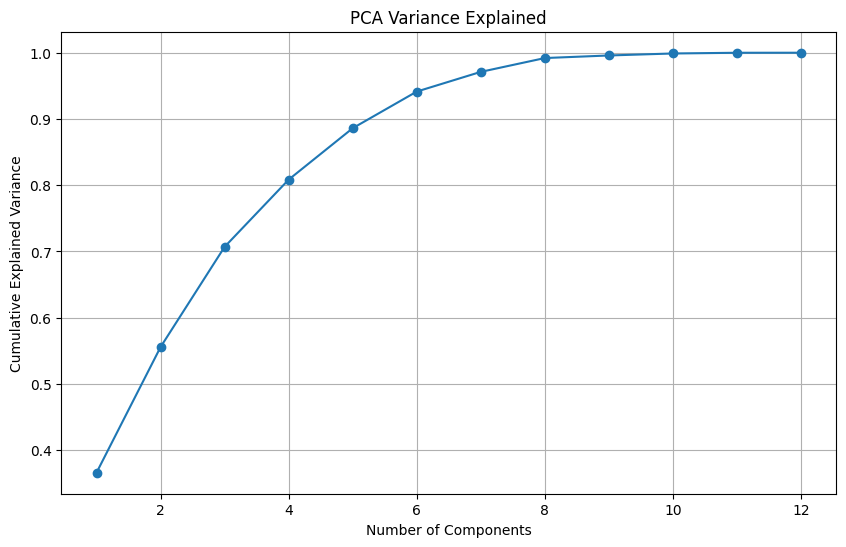

In [10]:
plt.figure(figsize=(10,6))

plt.plot(
    range(
        1,
        len(cumulative_variance)+1
    ),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Variance Explained")

plt.grid(True)

plt.show()

In [11]:
for i, value in enumerate(
        cumulative_variance,
        start=1
):
    if value >= 0.95:
        print(
            "95% variance reached at:",
            i,
            "components"
        )
        break

95% variance reached at: 7 components


In [12]:
pca_2d = PCA(n_components=2)

X_2d = pca_2d.fit_transform(
    X_scaled
)

print(X_2d.shape)

(520, 2)


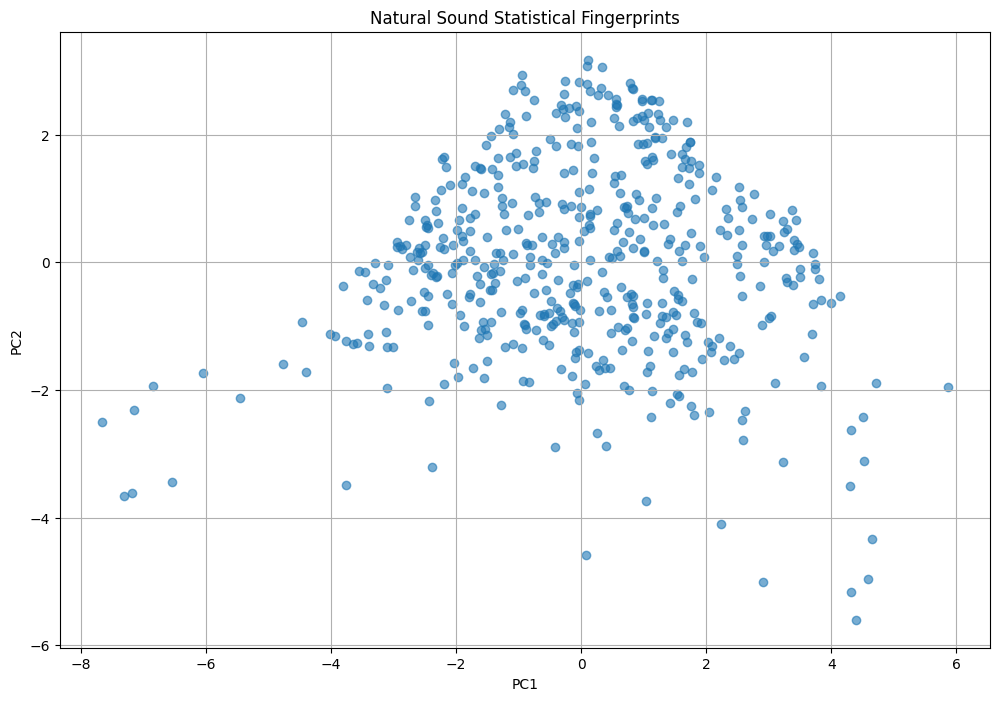

In [13]:
plt.figure(figsize=(12,8))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Natural Sound Statistical Fingerprints"
)

plt.grid(True)

plt.show()

In [14]:
from sklearn.cluster import KMeans

In [15]:
inertia = []

for k in range(1, 15):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(
        kmeans.inertia_
    )

print(inertia)

[6240.0, 4808.117716666816, 4092.539656228347, 3404.8000400320907, 2965.306922938344, 2606.5425546152537, 2344.6391821049683, 2081.4295590899414, 1880.9714885037577, 1766.9958905360022, 1632.8029021036855, 1538.3904033451045, 1455.2677512107764, 1353.2834251597474]


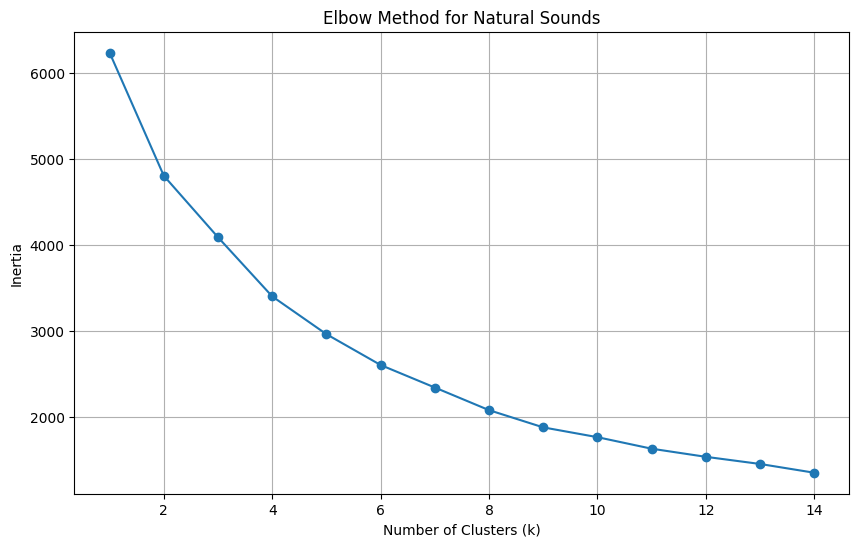

In [16]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1,15),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.title(
    "Elbow Method for Natural Sounds"
)

plt.grid(True)

plt.show()

In [17]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_scaled
)

print(clusters[:20])

[2 2 2 1 1 2 0 0 0 1 0 0 2 0 1 0 0 0 2 2]


In [18]:
features_df["cluster"] = clusters

features_df[
    ["category","cluster"]
].head(10)

,category,cluster
0,chirping_birds,2
1,thunderstorm,2
2,thunderstorm,2
3,crow,1
4,thunderstorm,1
5,pouring_water,2
6,water_drops,0
7,water_drops,0
8,water_drops,0
9,wind,1


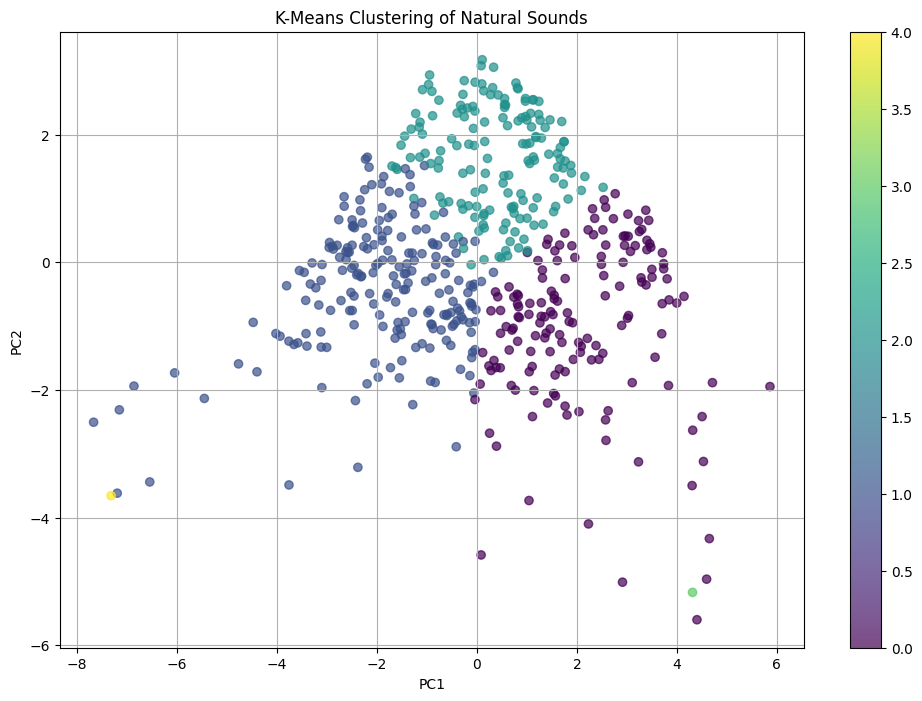

In [19]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=clusters,
    alpha=0.7
)

plt.colorbar(scatter)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "K-Means Clustering of Natural Sounds"
)

plt.grid(True)

plt.show()

In [20]:
pd.crosstab(
    features_df["cluster"],
    features_df["category"]
)

category,chirping_birds,crackling_fire,crickets,crow,frog,insects,pouring_water,rain,rooster,sea_waves,thunderstorm,water_drops,wind
cluster,,,,,,,,,,,,,
0,13,27,23,2,2,18,27,24,1,3,0,17,0
1,6,9,1,21,25,8,6,14,32,34,26,6,18
2,21,3,16,17,13,14,7,2,7,3,13,17,22
3,0,1,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0,0
